In [1]:
# IMPORTS & SETUP 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from statsmodels.tsa.seasonal import STL
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
import joblib
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_style("whitegrid")

# Paths
INPUT_PATH = r"D:\bhopal-pollutant-prediction\processed_data\bhopal_aqi_weather_final_clean.csv"
OUTPUT_DIR = Path(r"D:\bhopal-pollutant-prediction\processed_data")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Output paths
TRAIN_IMPUTED = OUTPUT_DIR / "bhopal_train_imputed_correct.csv"
TEST_IMPUTED = OUTPUT_DIR / "bhopal_test_imputed_correct.csv"
SCALER_PATH = OUTPUT_DIR / "scaler_correct.joblib"
IMPUTER_PATH = OUTPUT_DIR / "knn_imputer_correct.joblib"

In [2]:
#  LOAD ORIGINAL CLEAN DATA 
print("=" * 60)
print("STEP 1: LOADING ORIGINAL CLEAN DATA")
print("=" * 60)

df = pd.read_csv(INPUT_PATH, parse_dates=['datetime'])
df = df.sort_values('datetime').reset_index(drop=True)
df['datetime'] = pd.to_datetime(df['datetime'])
df = df.set_index('datetime')

print(f"✓ Data loaded successfully")
print(f"  Shape: {df.shape}")
print(f"  Date range: {df.index.min()} to {df.index.max()}")
print(f"  Total hours: {len(df)}")
print(f"  Total days: {(df.index.max() - df.index.min()).days} days")

# Show first few rows
display(df.head())

STEP 1: LOADING ORIGINAL CLEAN DATA
✓ Data loaded successfully
  Shape: (17040, 49)
  Date range: 2024-01-01 00:00:00 to 2025-12-10 23:00:00
  Total hours: 17040
  Total days: 709 days


,temp,feelslike,dew,humidity,precip,precipprob,windspeed,winddir,windgust,sealevelpressure,...,NH3_Paryavaran_Parisar,year,month,day,hour,dayofweek,hour_sin,hour_cos,month_sin,month_cos
datetime,,,,,,,,,,,,,,,,,,,,,
2024-01-01 00:00:00,63.8,63.8,59.6,86.39,0.0,0.0,6.5,98.5,8.3,1016.0,...,38.00,2024,1,1,0,0,0.000000,1.000000,0.5,0.866025
2024-01-01 01:00:00,63.2,63.2,59.1,86.36,0.0,0.0,6.5,103.2,11.2,1016.0,...,32.33,2024,1,1,1,0,0.258819,0.965926,0.5,0.866025
2024-01-01 02:00:00,62.0,62.0,60.5,95.03,0.0,0.0,2.2,360.0,11.0,1014.7,...,30.75,2024,1,1,2,0,0.500000,0.866025,0.5,0.866025
2024-01-01 03:00:00,61.8,61.8,58.6,89.12,0.0,0.0,5.6,104.3,10.5,1015.0,...,28.12,2024,1,1,3,0,0.707107,0.707107,0.5,0.866025
2024-01-01 04:00:00,59.1,59.1,57.6,94.97,0.0,0.0,4.7,96.1,9.4,1016.0,...,30.00,2024,1,1,4,0,0.866025,0.500000,0.5,0.866025


In [3]:
# CORRECT TEMPORAL SPLIT 
print("\n" + "=" * 60)
print("STEP 2: TEMPORAL SPLIT (80/20)")
print("=" * 60)

# Calculate 80% split point
split_idx = int(len(df) * 0.8)
split_date = df.index[split_idx]

print(f"Split at index: {split_idx}")
print(f"Split date: {split_date}")

# Get all rows before split date for train
train = df.loc[df.index < split_date].copy()
test = df.loc[df.index >= split_date].copy()

print(f"\n✓ SPLIT COMPLETE:")
print(f"Train: {train.shape} ({len(train)/len(df)*100:.1f}%)")
print(f"  Date range: {train.index.min()} to {train.index.max()}")
print(f"Test: {test.shape} ({len(test)/len(df)*100:.1f}%)")
print(f"  Date range: {test.index.min()} to {test.index.max()}")

# Verify no overlap
print(f"\n✓ VERIFICATION:")
print(f"Train max date: {train.index.max()}")
print(f"Test min date: {test.index.min()}")
print(f"Gap between sets: {(test.index.min() - train.index.max()).total_seconds()/3600:.1f} hours")

# Save raw split for reference
train.to_csv(OUTPUT_DIR / "train_raw_split.csv")
test.to_csv(OUTPUT_DIR / "test_raw_split.csv")


STEP 2: TEMPORAL SPLIT (80/20)
Split at index: 13632
Split date: 2025-07-22 00:00:00

✓ SPLIT COMPLETE:
Train: (13632, 49) (80.0%)
  Date range: 2024-01-01 00:00:00 to 2025-07-21 23:00:00
Test: (3408, 49) (20.0%)
  Date range: 2025-07-22 00:00:00 to 2025-12-10 23:00:00

✓ VERIFICATION:
Train max date: 2025-07-21 23:00:00
Test min date: 2025-07-22 00:00:00
Gap between sets: 1.0 hours


In [4]:
# IDENTIFY COLUMNS 
print("\n" + "=" * 60)
print("STEP 3: IDENTIFY COLUMN TYPES")
print("=" * 60)

# Pollutant columns
aqi_cols = [c for c in df.columns if any(p in c for p in 
            ['PM25','PM10','NO','NO2','SO2','CO','O3','NH3','Benzene'])]

# Weather columns
weather_cols = [c for c in df.columns if c in [
    'temp','feelslike','dew','humidity','precip','precipprob',
    'windspeed','winddir','windgust','sealevelpressure',
    'cloudcover','visibility','solarradiation','uvindex'
]]

# Time features
time_cols = ['year', 'month', 'day', 'hour', 'dayofweek', 
             'hour_sin', 'hour_cos', 'month_sin', 'month_cos']

print(f"Pollutant columns: {len(aqi_cols)}")
print(f"Weather columns: {len(weather_cols)}")
print(f"Time features: {len(time_cols)}")
print(f"Total columns: {len(aqi_cols) + len(weather_cols) + len(time_cols)}")

# Check missing values BEFORE imputation
print("\nMissing values in TRAIN set (before imputation):")
missing_train = train[aqi_cols + weather_cols].isnull().sum()
print(missing_train[missing_train > 0].head(10))


STEP 3: IDENTIFY COLUMN TYPES
Pollutant columns: 26
Weather columns: 14
Time features: 9
Total columns: 49

Missing values in TRAIN set (before imputation):
PM25_Idgah_Hills       7064
PM10_Idgah_Hills       7054
NO_Idgah_Hills         7052
SO2_Idgah_Hills        7052
CO_Idgah_Hills         7051
O3_Idgah_Hills         7052
Benzene_Idgah_Hills    7051
NO2_Idgah_Hills        7052
NH3_Idgah_Hills        7052
PM25_TT_Nagar          7023
dtype: int64



STEP 4: VISUALIZE MISSING VALUES PATTERN


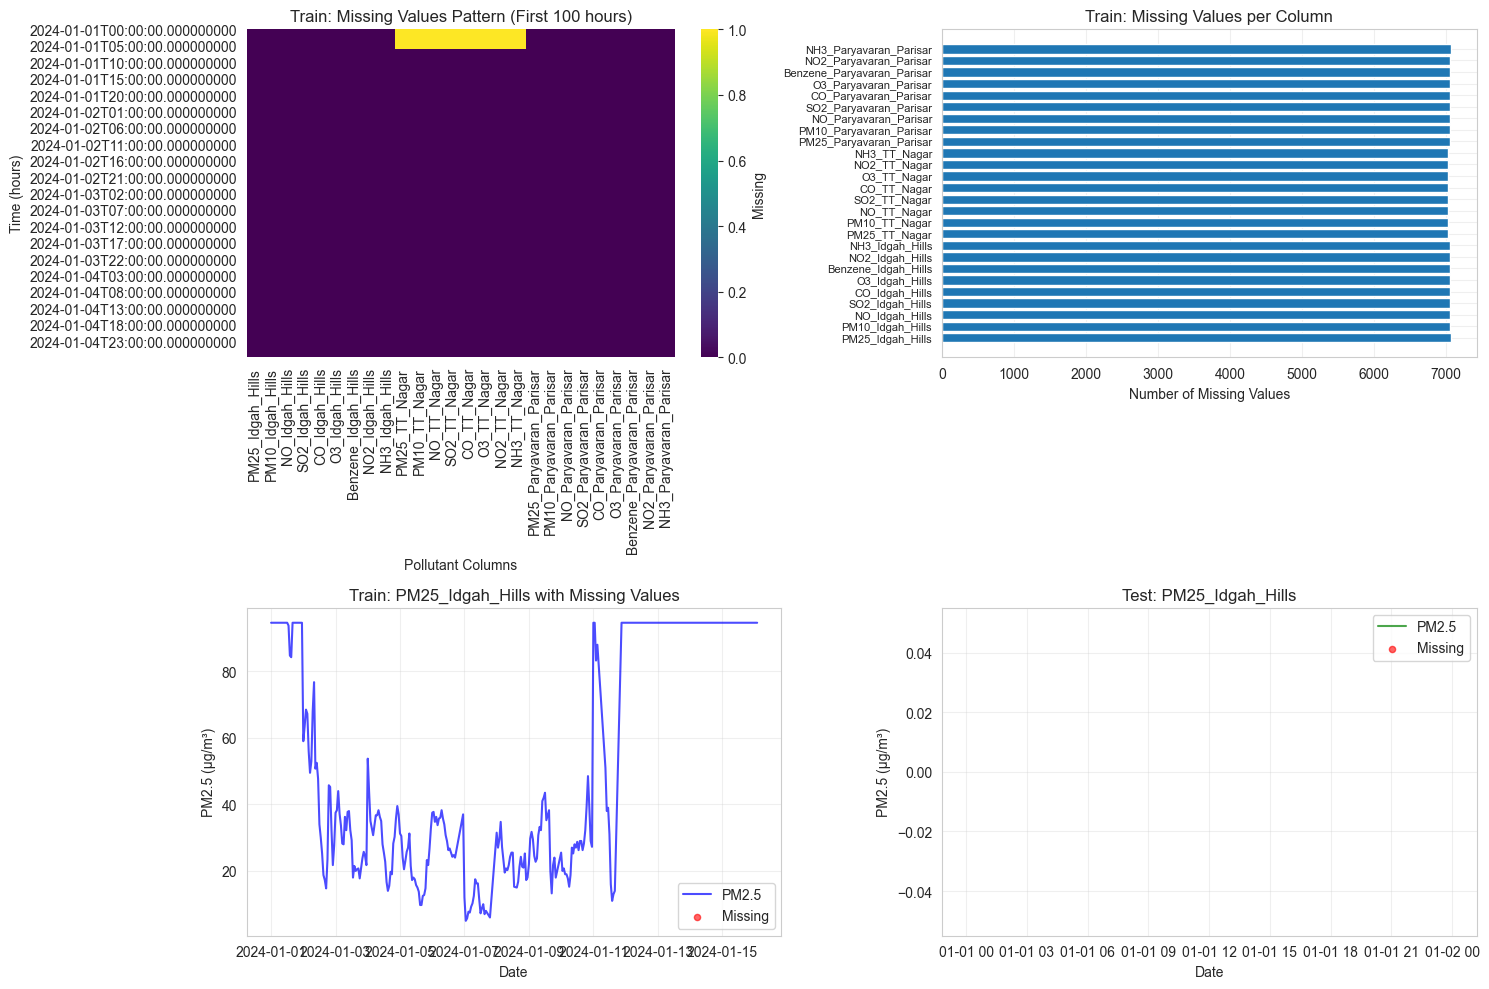

In [5]:
# VISUALIZE MISSING VALUES
print("\n" + "=" * 60)
print("STEP 4: VISUALIZE MISSING VALUES PATTERN")
print("=" * 60)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Missing values heatmap (first 100 rows)
sns.heatmap(train[aqi_cols].iloc[:100].isnull(), 
            cbar_kws={'label': 'Missing'}, 
            cmap='viridis', ax=axes[0, 0])
axes[0, 0].set_title('Train: Missing Values Pattern (First 100 hours)')
axes[0, 0].set_xlabel('Pollutant Columns')
axes[0, 0].set_ylabel('Time (hours)')

# Plot 2: Missing values by column
missing_counts = train[aqi_cols].isnull().sum()
axes[0, 1].barh(range(len(missing_counts)), missing_counts.values)
axes[0, 1].set_yticks(range(len(missing_counts)))
axes[0, 1].set_yticklabels(missing_counts.index, fontsize=8)
axes[0, 1].set_xlabel('Number of Missing Values')
axes[0, 1].set_title('Train: Missing Values per Column')
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Sample pollutant with missing values
sample_col = 'PM25_Idgah_Hills'
train_missing_mask = train[sample_col].isnull()
axes[1, 0].plot(train.index[:500], train[sample_col].iloc[:500], 
                'b-', alpha=0.7, label='PM2.5')
axes[1, 0].scatter(train.index[:500][train_missing_mask[:500]], 
                   train[sample_col].iloc[:500][train_missing_mask[:500]], 
                   c='red', s=20, label='Missing', alpha=0.6)
axes[1, 0].set_title(f'Train: {sample_col} with Missing Values')
axes[1, 0].set_xlabel('Date')
axes[1, 0].set_ylabel('PM2.5 (µg/m³)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Test set sample
axes[1, 1].plot(test.index[:200], test[sample_col].iloc[:200], 
                'g-', alpha=0.7, label='PM2.5')
test_missing_mask = test[sample_col].isnull()
if test_missing_mask.sum() > 0:
    axes[1, 1].scatter(test.index[:200][test_missing_mask[:200]], 
                       test[sample_col].iloc[:200][test_missing_mask[:200]], 
                       c='red', s=20, label='Missing', alpha=0.6)
axes[1, 1].set_title(f'Test: {sample_col}')
axes[1, 1].set_xlabel('Date')
axes[1, 1].set_ylabel('PM2.5 (µg/m³)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [6]:
# IMPUTATION FUNCTIONS 
print("\n" + "=" * 60)
print("STEP 5: IMPUTATION PIPELINE FUNCTIONS")
print("=" * 60)

def forward_fill_short_gaps(data, columns, limit=3):
    """Forward fill for short gaps"""
    data_filled = data.copy()
    for col in columns:
        data_filled[col] = data_filled[col].fillna(method='ffill', limit=limit)
    return data_filled

def stl_impute_column(train_series, test_series=None, period=24):
    """
    STL imputation for a single column
    Fits on train, applies to both train and test
    """
    train_result = train_series.copy()
    
    # Find missing indices in train
    train_missing_idx = train_series[train_series.isnull()].index
    
    if len(train_missing_idx) > 0:
        # Fill temporarily for STL fitting
        train_filled = train_series.interpolate(method='linear', limit_direction='both')
        
        try:
            # Fit STL
            stl = STL(train_filled, period=period, seasonal=13)
            res = stl.fit()
            
            # Reconstruct and fill missing
            reconstructed = res.trend + res.seasonal
            train_result.loc[train_missing_idx] = reconstructed.loc[train_missing_idx]
            
            # If test series provided, apply similar logic
            if test_series is not None:
                test_result = test_series.copy()
                test_missing_idx = test_series[test_series.isnull()].index
                
                if len(test_missing_idx) > 0:
                    # For test, use last known trend + seasonal pattern
                    last_trend = res.trend.iloc[-1]
                    
                    # Get seasonal values for corresponding hours
                    for idx in test_missing_idx:
                        hour = idx.hour
                        # Find similar hour in train's seasonal component
                        similar_hours = res.seasonal[res.seasonal.index.hour == hour]
                        seasonal_val = similar_hours.iloc[-1] if len(similar_hours) > 0 else 0
                        test_result.loc[idx] = last_trend + seasonal_val
                
                return train_result, test_result
            
        except Exception as e:
            print(f"STL failed: {e}, using linear interpolation")
            train_result = train_series.interpolate(method='linear', limit_direction='both')
    
    return train_result, test_series if test_series is not None else train_result

def knn_impute_with_scaling(train_data, test_data, columns, n_neighbors=5):
    """
    KNN imputation with proper scaling
    Fits on train, transforms both
    """
    scaler = StandardScaler()
    knn_imputer = KNNImputer(n_neighbors=n_neighbors, weights='distance')
    
    # Scale
    train_scaled = scaler.fit_transform(train_data[columns])
    test_scaled = scaler.transform(test_data[columns])
    
    # Fit on train
    train_imputed_scaled = knn_imputer.fit_transform(train_scaled)
    
    # Transform test
    test_imputed_scaled = knn_imputer.transform(test_scaled)
    
    # Inverse transform
    train_imputed = scaler.inverse_transform(train_imputed_scaled)
    test_imputed = scaler.inverse_transform(test_imputed_scaled)
    
    # Create DataFrames
    train_df = pd.DataFrame(train_imputed, columns=columns, index=train_data.index)
    test_df = pd.DataFrame(test_imputed, columns=columns, index=test_data.index)
    
    return train_df, test_df, scaler, knn_imputer

print("✓ Imputation functions defined")


STEP 5: IMPUTATION PIPELINE FUNCTIONS
✓ Imputation functions defined


In [7]:
#  APPLY IMPUTATION PIPELINE 
print("\n" + "=" * 60)
print("STEP 6: APPLY IMPUTATION PIPELINE")
print("=" * 60)

# Step 6.1: Forward fill
print("1. Forward fill short gaps (limit=3)...")
train_ff = forward_fill_short_gaps(train, aqi_cols, limit=3)
test_ff = forward_fill_short_gaps(test, aqi_cols, limit=3)

print(f"   Train missing after FF: {train_ff[aqi_cols].isnull().sum().sum()}")
print(f"   Test missing after FF: {test_ff[aqi_cols].isnull().sum().sum()}")

# Step 6.2: STL imputation for seasonal patterns
print("\n2. STL imputation for seasonal patterns...")
train_stl = train_ff.copy()
test_stl = test_ff.copy()

stl_imputed_cols = []
for col in aqi_cols:
    if train_stl[col].isnull().sum() > 0 or test_stl[col].isnull().sum() > 0:
        print(f"   Processing {col}...")
        train_stl[col], test_stl[col] = stl_impute_column(
            train_stl[col], test_stl[col], period=24
        )
        stl_imputed_cols.append(col)

print(f"   Applied STL to {len(stl_imputed_cols)} columns")
print(f"   Train missing after STL: {train_stl[aqi_cols].isnull().sum().sum()}")
print(f"   Test missing after STL: {test_stl[aqi_cols].isnull().sum().sum()}")

# Step 6.3: KNN for remaining missing values
print("\n3. KNN imputation for remaining values...")
all_impute_cols = aqi_cols + weather_cols

# Check which columns still have missing
train_missing = train_stl[all_impute_cols].isnull().sum()
test_missing = test_stl[all_impute_cols].isnull().sum()

cols_with_missing = list(set(
    train_missing[train_missing > 0].index.tolist() +
    test_missing[test_missing > 0].index.tolist()
))

if cols_with_missing:
    print(f"   Applying KNN to {len(cols_with_missing)} columns...")
    
    # Remove cyclical features from KNN
    knn_cols = [c for c in cols_with_missing if c not in ['hour_sin', 'hour_cos', 'month_sin', 'month_cos']]
    
    if knn_cols:
        train_knn_df, test_knn_df, scaler, knn_imputer = knn_impute_with_scaling(
            train_stl, test_stl, knn_cols, n_neighbors=5
        )
        
        # Update with KNN imputed values
        train_final = train_stl.copy()
        test_final = test_stl.copy()
        
        for col in knn_cols:
            train_final[col] = train_knn_df[col]
            test_final[col] = test_knn_df[col]
        
        # Save models
        joblib.dump(scaler, SCALER_PATH)
        joblib.dump(knn_imputer, IMPUTER_PATH)
        print(f"   ✓ Saved scaler and imputer")
    else:
        train_final = train_stl.copy()
        test_final = test_stl.copy()
else:
    print("   No missing values after STL - skipping KNN")
    train_final = train_stl.copy()
    test_final = test_stl.copy()

# Step 6.4: Final cleanup (if any missing remain)
print("\n4. Final cleanup...")
train_final = train_final.fillna(method='ffill').fillna(method='bfill')
test_final = test_final.fillna(method='ffill').fillna(method='bfill')

print(f"   ✓ Final train missing: {train_final.isnull().sum().sum()}")
print(f"   ✓ Final test missing: {test_final.isnull().sum().sum()}")


STEP 6: APPLY IMPUTATION PIPELINE
1. Forward fill short gaps (limit=3)...
   Train missing after FF: 181652
   Test missing after FF: 49230

2. STL imputation for seasonal patterns...
   Processing PM25_Idgah_Hills...
   Processing PM10_Idgah_Hills...
   Processing NO_Idgah_Hills...
   Processing SO2_Idgah_Hills...
   Processing CO_Idgah_Hills...
   Processing O3_Idgah_Hills...
   Processing Benzene_Idgah_Hills...
   Processing NO2_Idgah_Hills...
   Processing NH3_Idgah_Hills...
   Processing PM25_TT_Nagar...
   Processing PM10_TT_Nagar...
   Processing NO_TT_Nagar...
   Processing SO2_TT_Nagar...
   Processing CO_TT_Nagar...
   Processing O3_TT_Nagar...
   Processing NO2_TT_Nagar...
   Processing NH3_TT_Nagar...
   Processing PM25_Paryavaran_Parisar...
   Processing PM10_Paryavaran_Parisar...
   Processing NO_Paryavaran_Parisar...
   Processing SO2_Paryavaran_Parisar...
   Processing CO_Paryavaran_Parisar...
   Processing O3_Paryavaran_Parisar...
   Processing Benzene_Paryavaran_Pari


STEP 7: VISUALIZE IMPUTATION RESULTS


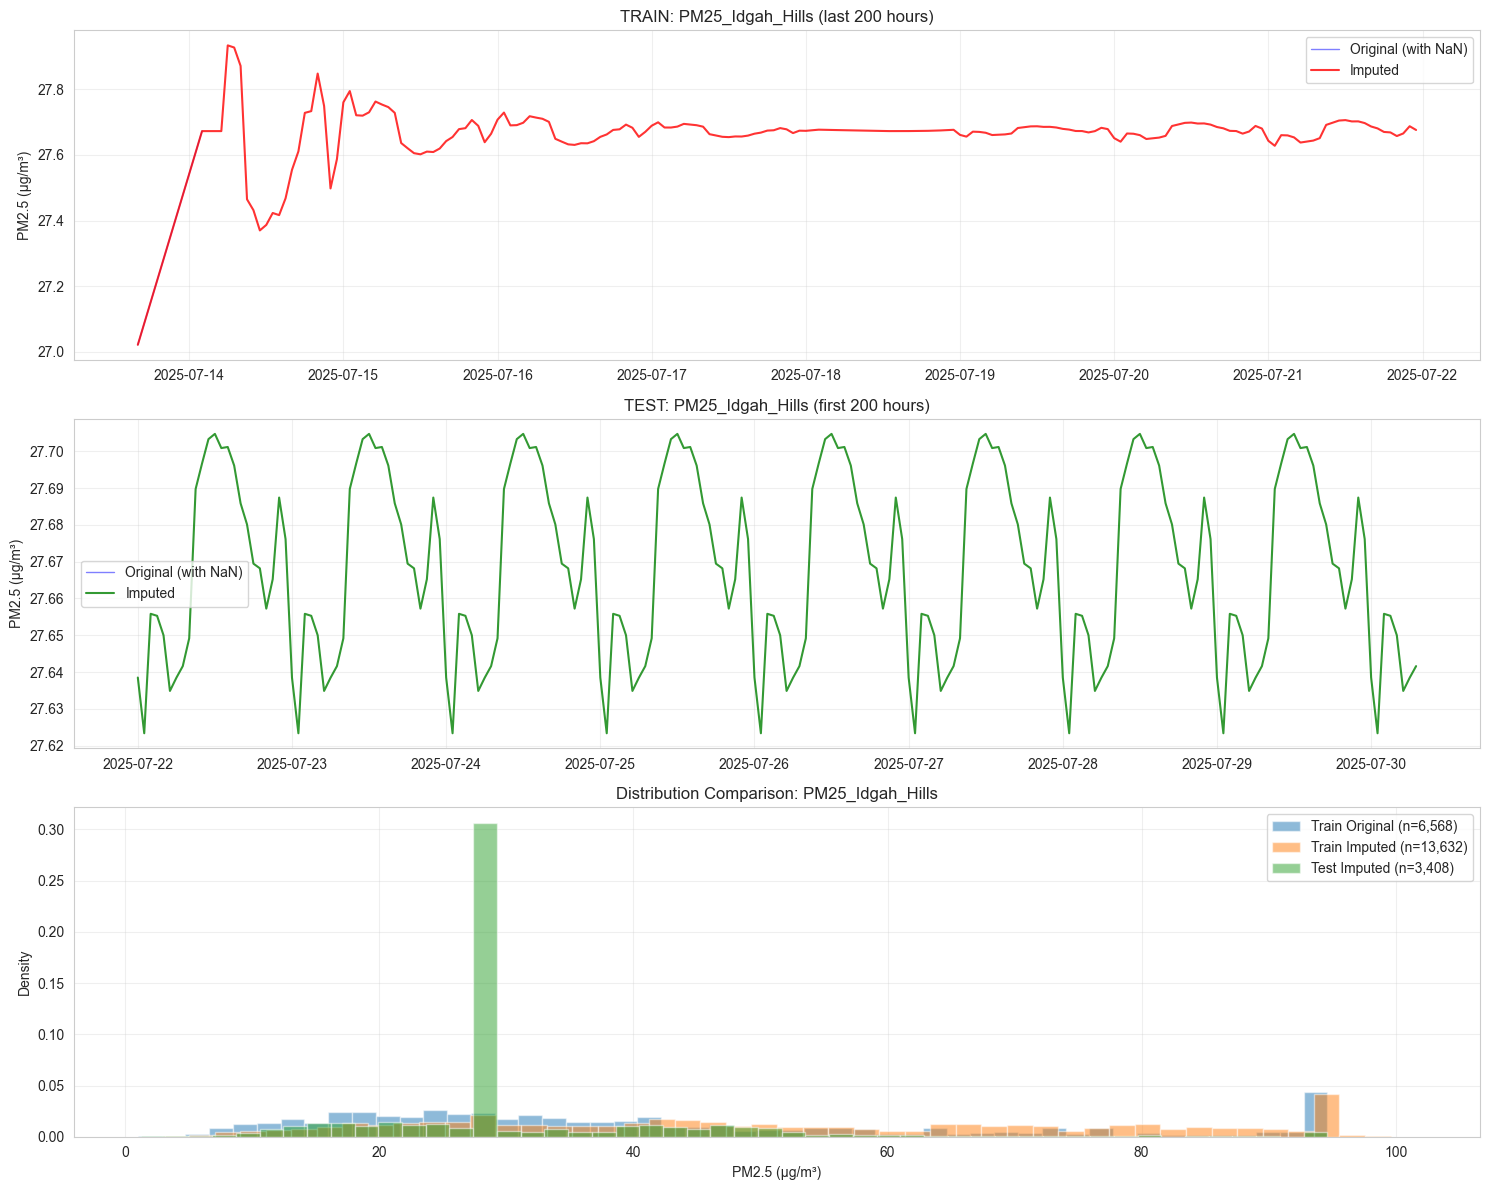

In [8]:
#  VISUALIZE IMPUTATION RESULTS
print("\n" + "=" * 60)
print("STEP 7: VISUALIZE IMPUTATION RESULTS")
print("=" * 60)

fig, axes = plt.subplots(3, 1, figsize=(15, 12))

# Plot 1: Train before/after
sample_col = 'PM25_Idgah_Hills'
train_idx = -200  # Last 200 hours of train

axes[0].plot(train.index[train_idx:], train[sample_col].iloc[train_idx:], 
             'b-', alpha=0.5, linewidth=1, label='Original (with NaN)')
axes[0].plot(train_final.index[train_idx:], train_final[sample_col].iloc[train_idx:], 
             'r-', alpha=0.8, linewidth=1.5, label='Imputed')
axes[0].set_title(f'TRAIN: {sample_col} (last 200 hours)')
axes[0].set_ylabel('PM2.5 (µg/m³)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Test before/after
test_idx = 200  # First 200 hours of test

axes[1].plot(test.index[:test_idx], test[sample_col].iloc[:test_idx], 
             'b-', alpha=0.5, linewidth=1, label='Original (with NaN)')
axes[1].plot(test_final.index[:test_idx], test_final[sample_col].iloc[:test_idx], 
             'g-', alpha=0.8, linewidth=1.5, label='Imputed')
axes[1].set_title(f'TEST: {sample_col} (first 200 hours)')
axes[1].set_ylabel('PM2.5 (µg/m³)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot 3: Distributions comparison
axes[2].hist(train[sample_col].dropna(), bins=50, alpha=0.5, 
             label=f'Train Original (n={train[sample_col].notna().sum():,})', density=True)
axes[2].hist(train_final[sample_col], bins=50, alpha=0.5, 
             label=f'Train Imputed (n={train_final[sample_col].notna().sum():,})', density=True)
axes[2].hist(test_final[sample_col], bins=50, alpha=0.5, 
             label=f'Test Imputed (n={test_final[sample_col].notna().sum():,})', density=True)
axes[2].set_title(f'Distribution Comparison: {sample_col}')
axes[2].set_xlabel('PM2.5 (µg/m³)')
axes[2].set_ylabel('Density')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
#  SAVE RESULTS
print("\n" + "=" * 60)
print("STEP 8: SAVE IMPUTED DATASETS")
print("=" * 60)

# Save imputed datasets
train_final.to_csv(TRAIN_IMPUTED)
test_final.to_csv(TEST_IMPUTED)

print(f"✓ Saved imputed training data: {TRAIN_IMPUTED}")
print(f"  Shape: {train_final.shape}")
print(f"  Date range: {train_final.index.min()} to {train_final.index.max()}")
print(f"  Missing values: {train_final.isnull().sum().sum()}")

print(f"\n✓ Saved imputed test data: {TEST_IMPUTED}")
print(f"  Shape: {test_final.shape}")
print(f"  Date range: {test_final.index.min()} to {test_final.index.max()}")
print(f"  Missing values: {test_final.isnull().sum().sum()}")

# Verify file sizes
train_size = TRAIN_IMPUTED.stat().st_size / (1024*1024)  # MB
test_size = TEST_IMPUTED.stat().st_size / (1024*1024)    # MB
print(f"\n✓ File sizes:")
print(f"  Train: {train_size:.1f} MB")
print(f"  Test: {test_size:.1f} MB")

# Summary statistics
print("\n" + "=" * 60)
print("SUMMARY STATISTICS")
print("=" * 60)

summary = pd.DataFrame({
    'train_original_mean': train[aqi_cols[:5]].mean(),
    'train_imputed_mean': train_final[aqi_cols[:5]].mean(),
    'test_original_mean': test[aqi_cols[:5]].mean(),
    'test_imputed_mean': test_final[aqi_cols[:5]].mean(),
    'difference_%': ((train_final[aqi_cols[:5]].mean() - train[aqi_cols[:5]].mean()) / 
                     train[aqi_cols[:5]].mean() * 100).round(2)
})

print(summary)


STEP 8: SAVE IMPUTED DATASETS
✓ Saved imputed training data: D:\bhopal-pollutant-prediction\processed_data\bhopal_train_imputed_correct.csv
  Shape: (13632, 49)
  Date range: 2024-01-01 00:00:00 to 2025-07-21 23:00:00
  Missing values: 0

✓ Saved imputed test data: D:\bhopal-pollutant-prediction\processed_data\bhopal_test_imputed_correct.csv
  Shape: (3408, 49)
  Date range: 2025-07-22 00:00:00 to 2025-12-10 23:00:00
  Missing values: 0

✓ File sizes:
  Train: 7.1 MB
  Test: 2.0 MB

SUMMARY STATISTICS
                  train_original_mean  train_imputed_mean  test_original_mean  \
PM25_Idgah_Hills            40.477335           52.392236           33.482771   
PM10_Idgah_Hills           106.419136          123.203592          107.865557   
NO_Idgah_Hills               2.380011            2.462523            1.894357   
SO2_Idgah_Hills              9.228606            9.066302           10.860380   
CO_Idgah_Hills               0.657156            0.744365            0.556425   

     

In [10]:
#  VERIFICATION 
print("\n" + "=" * 60)
print("STEP 9: FINAL VERIFICATION")
print("=" * 60)

# Load back to verify
print("Loading saved files for verification...")
train_loaded = pd.read_csv(TRAIN_IMPUTED, parse_dates=['datetime'], index_col='datetime')
test_loaded = pd.read_csv(TEST_IMPUTED, parse_dates=['datetime'], index_col='datetime')

print(f"✓ Train loaded: {train_loaded.shape}")
print(f"  Missing: {train_loaded.isnull().sum().sum()}")
print(f"  Date range: {train_loaded.index.min()} to {train_loaded.index.max()}")

print(f"\n✓ Test loaded: {test_loaded.shape}")
print(f"  Missing: {test_loaded.isnull().sum().sum()}")
print(f"  Date range: {test_loaded.index.min()} to {test_loaded.index.max()}")

# Check that split is correct
print("\n✓ Split verification:")
print(f"  Train max date: {train_loaded.index.max()}")
print(f"  Test min date: {test_loaded.index.min()}")
print(f"  Gap: {(test_loaded.index.min() - train_loaded.index.max()).total_seconds()/3600:.1f} hours")

# Check that models can be loaded
print("\n✓ Model verification:")
try:
    scaler_loaded = joblib.load(SCALER_PATH)
    imputer_loaded = joblib.load(IMPUTER_PATH)
    print("  ✓ Scaler and imputer loaded successfully")
except Exception as e:
    print(f"  ✗ Error loading models: {e}")

print("\n" + "=" * 60)
print("✅ DATA HANDLING PIPELINE COMPLETE!")
print("✅ READY FOR FEATURE ENGINEERING")
print("=" * 60)


STEP 9: FINAL VERIFICATION
Loading saved files for verification...
✓ Train loaded: (13632, 49)
  Missing: 0
  Date range: 2024-01-01 00:00:00 to 2025-07-21 23:00:00

✓ Test loaded: (3408, 49)
  Missing: 0
  Date range: 2025-07-22 00:00:00 to 2025-12-10 23:00:00

✓ Split verification:
  Train max date: 2025-07-21 23:00:00
  Test min date: 2025-07-22 00:00:00
  Gap: 1.0 hours

✓ Model verification:
  ✓ Scaler and imputer loaded successfully

✅ DATA HANDLING PIPELINE COMPLETE!
✅ READY FOR FEATURE ENGINEERING
